# A1 Fatal Traffic Accidents — Statistical Testing
**Source**: stg_accidents (PostgreSQL)  
**Goal**: 檢定各環境、當事者因素對事故特徵的影響是否統計顯著

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats
from sqlalchemy import create_engine

# 中文字型設定
_candidates = ['PingFang HK', 'PingFang SC', 'Heiti TC', 'STHeiti',
               'Hiragino Sans GB', 'Arial Unicode MS']
_available  = {f.name for f in fm.fontManager.ttflist}
_match      = next((f for f in _candidates if f in _available), None)
if _match:
    _font_path = fm.findfont(fm.FontProperties(family=_match))
    fm.fontManager.addfont(_font_path)
    _font_name = fm.FontProperties(fname=_font_path).get_name()
    sns.set_theme(style='whitegrid', rc={
        'font.family': 'sans-serif',
        'font.sans-serif': [_font_name, 'DejaVu Sans'],
        'axes.unicode_minus': False,
    })

engine = create_engine(
    'postgresql://postgres@localhost:5432/postgres',
    connect_args={'options': '-csearch_path=A1_Traffic_Fatal'}
)
print('Connected.')

Connected.


## 1. 載入資料

In [31]:
df = pd.read_sql('SELECT * FROM "A1_Traffic_Fatal".stg_accidents', engine)
acc = df[df['party_order'] == 1].copy()   # 事故層級
acc['multi_death'] = (acc['death_count'] > 1).astype(int)

party = df.copy()  # 當事者層級

print(f'事故數: {len(acc)}')
print(f'當事者數: {len(party)}')

事故數: 416
當事者數: 1077


---
## Part A — 環境因素 vs 死亡 (Chi-square / Fisher's Exact)
---

### A1. Fisher's Exact Test：路面狀態 vs 多人死亡
> Chi-square 在期望次數 < 5 時不可靠，Fisher's Exact 更適合小樣本 2x2 表

In [32]:
ct_road = pd.crosstab(acc['road_condition'], acc['multi_death'])
print('交叉表：路面狀態 x 多人死亡')
print(ct_road)

# Fisher's Exact (只適用 2x2)
if ct_road.shape == (2, 2):
    oddsratio, p = stats.fisher_exact(ct_road)
    print(f'\nOdds Ratio = {oddsratio:.4f}')
    print(f'p-value    = {p:.4f}')
    print(f'結論       : {"顯著相關 (p < 0.05)" if p < 0.05 else "無顯著相關 (p >= 0.05)"}')
else:
    chi2, p, dof, _ = stats.chi2_contingency(ct_road)
    print(f'Chi-square = {chi2:.4f}, p = {p:.4f}')

交叉表：路面狀態 x 多人死亡
multi_death       0  1
road_condition        
乾燥              368  8
濕潤               38  2

Odds Ratio = 2.4211
p-value    = 0.2484
結論       : 無顯著相關 (p >= 0.05)


### A2. Chi-square：號誌種類 vs 多人死亡

In [33]:
ct_signal = pd.crosstab(acc['signal_type'], acc['multi_death'])
print('交叉表：號誌種類 x 多人死亡')
print(ct_signal)

chi2, p, dof, expected = stats.chi2_contingency(ct_signal)
low_expected = (expected < 5).sum()
print(f'\nChi-square = {chi2:.4f}')
print(f'p-value    = {p:.4f}')
print(f'期望次數 < 5 的格數: {low_expected} (共 {expected.size} 格)')
print(f'結論       : {"顯著相關 (p < 0.05)" if p < 0.05 else "無顯著相關 (p >= 0.05)"}')

交叉表：號誌種類 x 多人死亡
multi_death         0  1
signal_type             
無號誌               276  8
行車管制號誌             89  2
行車管制號誌(附設行人專用號誌)   18  0
閃光號誌               23  0

Chi-square = 1.2329
p-value    = 0.7451
期望次數 < 5 的格數: 3 (共 8 格)
結論       : 無顯著相關 (p >= 0.05)


---
## Part B — 當事者年齡分析 (Kruskal-Wallis / Mann-Whitney U)
---

### B1. Kruskal-Wallis：各車種的年齡分布是否有顯著差異？

In [34]:
target_vehicles = ['機車', '小客車(含客、貨兩用)', '人']
party_age = party[party['party_type_major'].isin(target_vehicles)].dropna(subset=['age'])

groups = [g['age'].values for _, g in party_age.groupby('party_type_major')]
labels = party_age['party_type_major'].unique().tolist()

stat, p = stats.kruskal(*groups)
print(f'Kruskal-Wallis H = {stat:.4f}')
print(f'p-value          = {p:.4f}')
print(f'結論             : {"各車種年齡分布有顯著差異 (p < 0.05)" if p < 0.05 else "無顯著差異 (p >= 0.05)"}')

# 各組描述統計
print('\n各車種年齡描述統計：')
print(party_age.groupby('party_type_major')['age'].describe().round(1))

Kruskal-Wallis H = 3.8632
p-value          = 0.1449
結論             : 無顯著差異 (p >= 0.05)

各車種年齡描述統計：
                  count  mean   std   min   25%   50%   75%   max
party_type_major                                                 
人                 169.0  48.8  26.2  -1.0  28.0  52.0  73.0  94.0
小客車(含客、貨兩用)       234.0  45.5  16.0  -1.0  34.0  46.0  56.0  84.0
機車                329.0  45.4  20.2  14.0  25.0  45.0  63.0  87.0


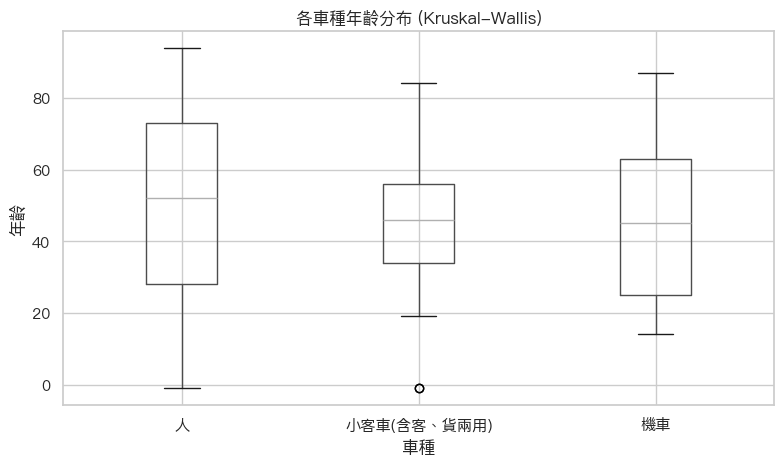

In [35]:
# Box plot 視覺化
fig, ax = plt.subplots(figsize=(8, 5))
party_age.boxplot(column='age', by='party_type_major', ax=ax)
ax.set_title('各車種年齡分布 (Kruskal-Wallis)')
ax.set_xlabel('車種')
ax.set_ylabel('年齡')
plt.suptitle('')
plt.tight_layout()
plt.savefig('../Images/age_by_vehicle_boxplot.png', dpi=150)
plt.show()

### B2. Mann-Whitney U：機車族 vs 行人 年齡差異

In [36]:
male_age   = party[(party['gender'] == '男') & (party['age'] >= 0)]['age']
female_age = party[(party['gender'] == '女') & (party['age'] >= 0)]['age']

stat, p = stats.mannwhitneyu(male_age, female_age, alternative='two-sided')

print(f'男性年齡 — 中位數: {male_age.median():.1f}, 平均: {male_age.mean():.1f}')
print(f'女性年齡 — 中位數: {female_age.median():.1f}, 平均: {female_age.mean():.1f}')
print(f'\nMann-Whitney U = {stat:.1f}')
print(f'p-value        = {p:.4f}')
print(f'結論           : {"年齡分布有顯著差異 (p < 0.05)" if p < 0.05 else "無顯著差異 (p >= 0.05)"}')

男性年齡 — 中位數: 46.0, 平均: 46.2
女性年齡 — 中位數: 51.5, 平均: 50.3

Mann-Whitney U = 72241.5
p-value        = 0.0033
結論           : 年齡分布有顯著差異 (p < 0.05)


### B3. Mann-Whitney U：男性 vs 女性 年齡差異

In [37]:
male_age   = party[party['gender'] == '男']['age'].dropna()
female_age = party[party['gender'] == '女']['age'].dropna()

stat, p = stats.mannwhitneyu(male_age, female_age, alternative='two-sided')

print(f'男性年齡 — 中位數: {male_age.median():.1f}, 平均: {male_age.mean():.1f}')
print(f'女性年齡 — 中位數: {female_age.median():.1f}, 平均: {female_age.mean():.1f}')
print(f'\nMann-Whitney U = {stat:.1f}')
print(f'p-value        = {p:.4f}')
print(f'結論           : {"年齡分布有顯著差異 (p < 0.05)" if p < 0.05 else "無顯著差異 (p >= 0.05)"}')

男性年齡 — 中位數: 45.0, 平均: 45.9
女性年齡 — 中位數: 51.0, 平均: 50.1

Mann-Whitney U = 72921.5
p-value        = 0.0031
結論           : 年齡分布有顯著差異 (p < 0.05)


---
## Part C — 連續變數相關性 (Spearman)
---

### C1. Spearman 相關：速限 vs 死亡人數

Spearman r = 0.0655
p-value    = 0.1823
結論       : 無顯著相關 (p >= 0.05)
方向       : 速限越高死亡越多


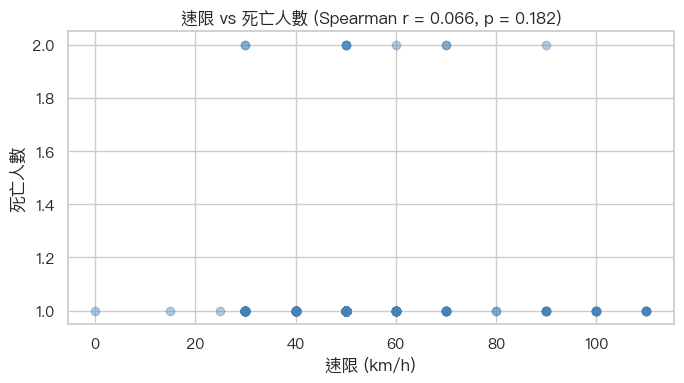

In [38]:
acc_speed = acc.dropna(subset=['speed_limit'])

corr, p = stats.spearmanr(acc_speed['speed_limit'], acc_speed['death_count'])

print(f'Spearman r = {corr:.4f}')
print(f'p-value    = {p:.4f}')
print(f'結論       : {"顯著相關 (p < 0.05)" if p < 0.05 else "無顯著相關 (p >= 0.05)"}')
print(f'方向       : {"速限越高死亡越多" if corr > 0 else "速限越高死亡越少"}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(acc_speed['speed_limit'], acc_speed['death_count'],
           alpha=0.4, color='steelblue')
ax.set_xlabel('速限 (km/h)')
ax.set_ylabel('死亡人數')
ax.set_title(f'速限 vs 死亡人數 (Spearman r = {corr:.3f}, p = {p:.3f})')
plt.tight_layout()
plt.savefig('../Images/spearman_speed_death.png', dpi=150)
plt.show()

### C2. Spearman 相關：事故小時 vs 死亡人數

In [39]:
corr, p = stats.spearmanr(acc['accident_hour'], acc['death_count'])

print(f'Spearman r = {corr:.4f}')
print(f'p-value    = {p:.4f}')
print(f'結論       : {"顯著相關 (p < 0.05)" if p < 0.05 else "無顯著相關 (p >= 0.05)"}')

Spearman r = -0.0448
p-value    = 0.3619
結論       : 無顯著相關 (p >= 0.05)


---
## Part D — 彙整所有檢定結果
---

In [40]:
summary = [
    ('Fisher Exact',    '路面狀態 vs 多人死亡',     '事故層級', '小樣本 2x2'),
    ('Chi-square',      '號誌種類 vs 多人死亡',     '事故層級', '注意期望次數'),
    ('Kruskal-Wallis',  '各車種年齡分布差異',        '當事者層級', '機車/小客車/人'),
    ('Mann-Whitney U',  '機車族 vs 行人 年齡',      '當事者層級', ''),
    ('Mann-Whitney U',  '男性 vs 女性 年齡',        '當事者層級', ''),
    ('Spearman',        '速限 vs 死亡人數',          '事故層級', ''),
    ('Spearman',        '事故小時 vs 死亡人數',      '事故層級', ''),
]

print('=== 檢定彙整 ===')
print(f'{"檢定方法":<18} {"問題":<22} {"資料粒度":<12} {"備註"}')
print('-' * 70)
for row in summary:
    print(f'{row[0]:<18} {row[1]:<22} {row[2]:<12} {row[3]}')

=== 檢定彙整 ===
檢定方法               問題                     資料粒度         備註
----------------------------------------------------------------------
Fisher Exact       路面狀態 vs 多人死亡           事故層級         小樣本 2x2
Chi-square         號誌種類 vs 多人死亡           事故層級         注意期望次數
Kruskal-Wallis     各車種年齡分布差異              當事者層級        機車/小客車/人
Mann-Whitney U     機車族 vs 行人 年齡           當事者層級        
Mann-Whitney U     男性 vs 女性 年齡            當事者層級        
Spearman           速限 vs 死亡人數             事故層級         
Spearman           事故小時 vs 死亡人數           事故層級         
